In [1]:
import boto3
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

In [2]:
nbm_s3_url = "s3://processed-data-809918852303-us-east-1-an/nbm_mint_final_2020_2026_7days.parquet"
nbm_df = pd.read_parquet(nbm_s3_url)

In [3]:
nbm_df['date'] = pd.to_datetime(nbm_df['date'])
nbm_df = nbm_df.sort_values(by=['public_zone', 'date', 'week', 'forecast_day'])

In [4]:
prism_s3_url = 's3://processed-data-809918852303-us-east-1-an/prism_mint_final_2020_2026.parquet'
prism_df = pd.read_parquet(prism_s3_url)

In [6]:
# make sure rolling doesn't include current day!
prism_df['60daywindow_prism'] = (
    prism_df.groupby('unique_zone_str')['mint_value']
    .transform(lambda x: x.shift(1).rolling(window=60, min_periods=60).mean())
)

prism_df['7daywindow_prism'] = (
    prism_df.groupby('unique_zone_str')['mint_value']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=7).mean())
)

In [7]:
# merge prism_df and nbm_df on date and zone string to ensure perfect matching
merged_df = pd.merge(
    nbm_df, 
    prism_df, 
    on=['date', 'unique_zone_str'], 
    suffixes=('_nbm', '_prism')
)

#merged_df = merged_df.rename(columns={'mint_value': 'min_temp_f_nbm', 'min_temp_f': 'min_temp_f_prism'})

# calculate the temp difference in F (NBM minus PRISM)
merged_df['nbm_minus_obs'] = merged_df['mint_value_nbm'] - merged_df['mint_value_prism']

In [8]:
merged_df

,public_zone,date,week_nbm,mint_value_nbm,forecast_day,unique_zone_str,model_run_date,zone_id_nbm,state_nbm,name_nbm,global_zone_id,mint_value_prism,week_prism,zone_id_prism,state_prism,name_prism,60daywindow_prism,7daywindow_prism,nbm_minus_obs
0,1,2020-10-21,43,59.489726,1,AL_001,2020-10-20,001,AL,Lauderdale,1,56.834346,43,001,AL,Lauderdale,58.933126,45.827951,2.655380
1,1,2020-10-22,43,62.359589,1,AL_001,2020-10-21,001,AL,Lauderdale,1,57.892283,43,001,AL,Lauderdale,58.774652,47.491688,4.467306
2,1,2020-10-22,43,61.571918,2,AL_001,2020-10-20,001,AL,Lauderdale,1,57.892283,43,001,AL,Lauderdale,58.774652,47.491688,3.679635
3,1,2020-10-23,43,64.229452,1,AL_001,2020-10-22,001,AL,Lauderdale,1,60.500627,43,001,AL,Lauderdale,58.654983,49.234070,3.728825
4,1,2020-10-23,43,63.287671,2,AL_001,2020-10-21,001,AL,Lauderdale,1,60.500627,43,001,AL,Lauderdale,58.654983,49.234070,2.787044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65680995,3850,2026-07-18,29,64.980606,3,WY_199,2026-07-15,199,WY,Sheridan Foothills,3850,64.308634,29,199,WY,Sheridan Foothills,49.530439,62.911442,0.671972
65680996,3850,2026-07-18,29,64.501818,4,WY_199,2026-07-14,199,WY,Sheridan Foothills,3850,64.308634,29,199,WY,Sheridan Foothills,49.530439,62.911442,0.193184
65680997,3850,2026-07-18,29,64.557576,5,WY_199,2026-07-13,199,WY,Sheridan Foothills,3850,64.308634,29,199,WY,Sheridan Foothills,49.530439,62.911442,0.248941
65680998,3850,2026-07-18,29,65.373333,6,WY_199,2026-07-12,199,WY,Sheridan Foothills,3850,64.308634,29,199,WY,Sheridan Foothills,49.530439,62.911442,1.064699


In [9]:
merged_df = merged_df.drop(columns=['week_nbm', 'zone_id_nbm', 'state_nbm', 'name_nbm', 'zone_id_nbm', 'state_nbm', 'name_nbm', 'global_zone_id', 'unique_zone_str'])

In [10]:
merged_df = merged_df.rename(columns={'week_prism': 'week', 'state_prism': 'state', 'name_prism':'name', 'zone_id_prism':'zone_id'})

column_order = [
        'public_zone', 'date', 'week', 'forecast_day', 'nbm_minus_obs', 'state', 'zone_id', 'name', 
        'model_run_date', 'mint_value_nbm', 'mint_value_prism', '60daywindow_prism', '7daywindow_prism'
]
merged_df = merged_df[column_order]

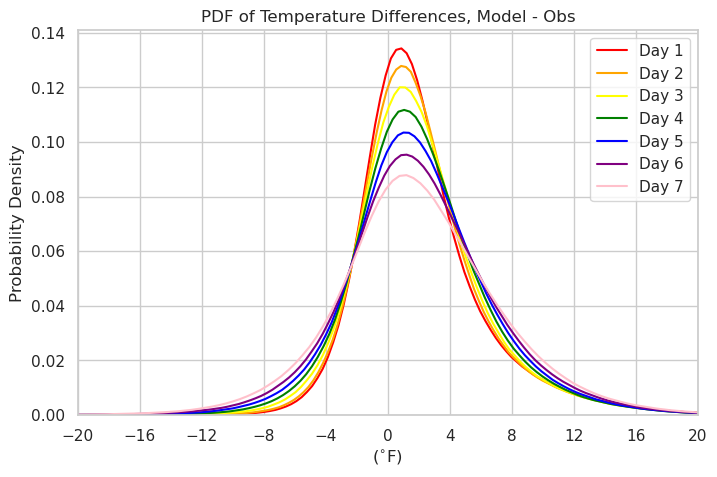

In [13]:
# # trying to plot PDF
# sns.set_theme(style="whitegrid")
# plt.figure(figsize=(8, 5))
# plt.xlim(-15, 15)
# plt.xticks(np.arange(-20, 24, 4)) 

# # get every curve in
# sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 1, 'nbm_minus_obs'], fill=False, color='red', bw_adjust=1, label='Day 1')
# sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 2, 'nbm_minus_obs'], fill=False, color='orange', bw_adjust=1, label='Day 2')
# sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 3, 'nbm_minus_obs'], fill=False, color='yellow', bw_adjust=1, label='Day 3')
# sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 4, 'nbm_minus_obs'], fill=False, color='green', bw_adjust=1, label='Day 4')
# sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 5, 'nbm_minus_obs'], fill=False, color='blue', bw_adjust=1, label='Day 5')
# sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 6, 'nbm_minus_obs'], fill=False, color='purple', bw_adjust=1, label='Day 6')
# sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 7, 'nbm_minus_obs'], fill=False, color='pink', bw_adjust=1, label='Day 7')

# plt.xlabel('($^{\circ}$F)')
# plt.ylabel('Probability Density')
# plt.title(f"PDF of Temperature Differences, Model - Obs")
# plt.legend(loc='upper right')

# plt.savefig('pdf_plot_mint.png')
# plt.show()

In [9]:
# #temp_thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
# #temp_thresholds = [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# #temp_thresholds = [-10, 10, -9, 9, -8, 8, -7, 7, -6, 6, -5, 5, -4, 4, -3, 3, -2, 2, -1 , 1]
# temp_thresholds = [2, 5, 8]
# forecast_days = [1, 2, 3, 4, 5, 6, 7]


# for temp in temp_thresholds:
#     for day in forecast_days:
#         if temp > 0:
#             mask = (merged_df.loc[merged_df['forecast_day'] == day, 'nbm_minus_obs'] >= temp)
#             column_name = 'outside_' + str(temp) + 'F'
#             merged_df[column_name] = mask
#             print(f"forecast day {day} total count above {temp}F is {merged_df[column_name].sum()}")
#             print(f"forecast day {day} total percentage above {temp}F is {(merged_df[column_name].sum()/len(merged_df))*100:.3f}%\n")
#         else:
#             mask = (merged_df.loc[merged_df['forecast_day'] == day, 'nbm_minus_obs'] <= temp)
#             column_name = 'outside_' + str(temp) + 'F'
#             merged_df[column_name] = mask
#             print(f"forecast day {day} total count below {temp}F is {merged_df[column_name].sum()}")
#             print(f"forecast day {day} total percentage below {temp}F is {(merged_df[column_name].sum()/len(merged_df))*100:.3f}%\n")

In [10]:
# temp_thresholds = [2, 5, 8]
# forecast_days = [1, 2, 3, 4, 5, 6, 7]


# for temp in temp_thresholds:
#     for day in forecast_days:
#         mask = (merged_df.loc[merged_df['forecast_day'] == day, 'nbm_minus_obs'] >= temp) | (merged_df.loc[merged_df['forecast_day'] == day, 'nbm_minus_obs'] <= -temp)
#         column_name = 'outside_' + str(temp) + 'F'
#         merged_df[column_name] = mask
#         print(f"forecast day {day} total count outside {temp}F is {merged_df[column_name].sum()}")
#         print(f"forecast day {day} total percentage outside {temp}F is {(merged_df[column_name].sum()/len(merged_df))*100:.3f}%\n")

In [12]:
merged_df['nbm_minus_obs_window_60d'] = merged_df['mint_value_nbm'] - merged_df['60daywindow_prism']
merged_df['nbm_minus_obs_window_7d'] = merged_df['mint_value_nbm'] - merged_df['7daywindow_prism']

In [13]:
merged_df

,public_zone,date,week,forecast_day,nbm_minus_obs,state,zone_id,name,model_run_date,mint_value_nbm,mint_value_prism,60daywindow_prism,7daywindow_prism,nbm_minus_obs_window_60d,nbm_minus_obs_window_7d
0,1,2020-10-21,43,1,2.655380,AL,001,Lauderdale,2020-10-20,59.489726,56.834346,58.933126,45.827951,0.556600,13.661775
1,1,2020-10-22,43,1,4.467306,AL,001,Lauderdale,2020-10-21,62.359589,57.892283,58.774652,47.491688,3.584937,14.867901
2,1,2020-10-22,43,2,3.679635,AL,001,Lauderdale,2020-10-20,61.571918,57.892283,58.774652,47.491688,2.797266,14.080230
3,1,2020-10-23,43,1,3.728825,AL,001,Lauderdale,2020-10-22,64.229452,60.500627,58.654983,49.234070,5.574469,14.995382
4,1,2020-10-23,43,2,2.787044,AL,001,Lauderdale,2020-10-21,63.287671,60.500627,58.654983,49.234070,4.632688,14.053602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65680995,3850,2026-07-18,29,3,0.671972,WY,199,Sheridan Foothills,2026-07-15,64.980606,64.308634,49.530439,62.911442,15.450167,2.069164
65680996,3850,2026-07-18,29,4,0.193184,WY,199,Sheridan Foothills,2026-07-14,64.501818,64.308634,49.530439,62.911442,14.971379,1.590376
65680997,3850,2026-07-18,29,5,0.248941,WY,199,Sheridan Foothills,2026-07-13,64.557576,64.308634,49.530439,62.911442,15.027136,1.646134
65680998,3850,2026-07-18,29,6,1.064699,WY,199,Sheridan Foothills,2026-07-12,65.373333,64.308634,49.530439,62.911442,15.842894,2.461892


In [16]:
print(merged_df['nbm_minus_obs'].describe().round(2))
print(merged_df['nbm_minus_obs_window_60d'].describe().round(2))
print(merged_df['nbm_minus_obs_window_7d'].describe().round(2))

count    65681000.00
mean            2.07
std             4.56
min           -34.82
25%            -0.69
50%             1.63
75%             4.40
max            54.27
Name: nbm_minus_obs, dtype: float64
count    65681000.00
mean            2.33
std            11.06
min           -58.68
25%            -4.90
50%             2.82
75%             9.91
max            45.58
Name: nbm_minus_obs_window_60d, dtype: float64
count    65681000.00
mean            2.12
std             8.05
min           -46.65
25%            -2.61
50%             1.85
75%             6.74
max            54.80
Name: nbm_minus_obs_window_7d, dtype: float64


In [15]:
merged_df

,public_zone,date,week,forecast_day,nbm_minus_obs,state,zone_id,name,model_run_date,mint_value_nbm,mint_value_prism,60daywindow_prism,7daywindow_prism,nbm_minus_obs_window_60d,nbm_minus_obs_window_7d
0,1,2020-10-21,43,1,2.655380,AL,001,Lauderdale,2020-10-20,59.489726,56.834346,58.933126,45.827951,0.556600,13.661775
1,1,2020-10-22,43,1,4.467306,AL,001,Lauderdale,2020-10-21,62.359589,57.892283,58.774652,47.491688,3.584937,14.867901
2,1,2020-10-22,43,2,3.679635,AL,001,Lauderdale,2020-10-20,61.571918,57.892283,58.774652,47.491688,2.797266,14.080230
3,1,2020-10-23,43,1,3.728825,AL,001,Lauderdale,2020-10-22,64.229452,60.500627,58.654983,49.234070,5.574469,14.995382
4,1,2020-10-23,43,2,2.787044,AL,001,Lauderdale,2020-10-21,63.287671,60.500627,58.654983,49.234070,4.632688,14.053602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65680995,3850,2026-07-18,29,3,0.671972,WY,199,Sheridan Foothills,2026-07-15,64.980606,64.308634,49.530439,62.911442,15.450167,2.069164
65680996,3850,2026-07-18,29,4,0.193184,WY,199,Sheridan Foothills,2026-07-14,64.501818,64.308634,49.530439,62.911442,14.971379,1.590376
65680997,3850,2026-07-18,29,5,0.248941,WY,199,Sheridan Foothills,2026-07-13,64.557576,64.308634,49.530439,62.911442,15.027136,1.646134
65680998,3850,2026-07-18,29,6,1.064699,WY,199,Sheridan Foothills,2026-07-12,65.373333,64.308634,49.530439,62.911442,15.842894,2.461892


In [17]:
BUCKET_NAME = 'processed-data-809918852303-us-east-1-an'

merged_df.to_parquet('mint_merged_df_7days_FULL.parquet', index=False)
s3 = boto3.client('s3')
s3.upload_file('mint_merged_df_7days_FULL.parquet', BUCKET_NAME, 'mint_merged_df_7days_FULL.parquet')
print("PARQUET complete / uploaded now")

PARQUET complete / uploaded now


In [12]:
#create boolean masks for differences outside of 2°F, 5°F, and 8°F 
mask_2F = (merged_df['nbm_minus_obs'] >= 2) | (merged_df['nbm_minus_obs'] <= -2)
merged_df['outside_2F'] = mask_2F

mask_5F = (merged_df['nbm_minus_obs'] >= 5) | (merged_df['nbm_minus_obs'] <= -5)
merged_df['outside_5F'] = mask_5F

mask_8F = (merged_df['nbm_minus_obs'] >= 8) | (merged_df['nbm_minus_obs'] <= -8)
merged_df['outside_8F'] = mask_8F

In [13]:
print(f"total count outside of ±2F is {merged_df['outside_2F'].sum()}")
print(f"total count outside of ±5F is {merged_df['outside_5F'].sum()}")
print(f"total count outside of ±8F is {merged_df['outside_8F'].sum()}\n")

print(f"total percentage outside of ±2F is {(merged_df['outside_2F'].sum()/len(merged_df))*100:.3f}%")
print(f"total percentage outside of ±5F is {(merged_df['outside_5F'].sum()/len(merged_df))*100:.3f}%")
print(f"total percentage outside of ±8F is {(merged_df['outside_8F'].sum()/len(merged_df))*100:.3f}%")

total count outside of ±2F is 30816795
total count outside of ±5F is 12867885
total count outside of ±8F is 5309406

total percentage outside of ±2F is 60.948%
total percentage outside of ±5F is 25.450%
total percentage outside of ±8F is 10.501%


In [14]:
merged_df

,public_zone,date,week,forecast_day,nbm_minus_obs,nbm_minus_obs_window,state,zone_id,name,model_run_date,mint_value,min_temp_f,60daywindow_prism,outside_2F,outside_5F,outside_8F
0,1,2020-10-21,43,1,2.655380,0.715074,AL,001,Lauderdale,2020-10-20,59.489726,56.834346,58.774652,True,False,False
1,1,2020-10-22,43,1,4.467306,3.704606,AL,001,Lauderdale,2020-10-21,62.359589,57.892283,58.654983,True,False,False
2,1,2020-10-22,43,2,3.679635,2.916935,AL,001,Lauderdale,2020-10-20,61.571918,57.892283,58.654983,True,False,False
3,1,2020-10-23,43,1,3.728825,5.689078,AL,001,Lauderdale,2020-10-22,64.229452,60.500627,58.540374,True,False,False
4,1,2020-10-23,43,2,2.787044,4.747297,AL,001,Lauderdale,2020-10-21,63.287671,60.500627,58.540374,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50562045,3850,2026-04-30,18,3,5.437495,3.088169,WY,199,Sheridan Foothills,2026-04-27,32.214545,26.777050,29.126377,True,True,False
50562046,3850,2026-04-30,18,4,6.102950,3.753623,WY,199,Sheridan Foothills,2026-04-26,32.880000,26.777050,29.126377,True,True,False
50562047,3850,2026-04-30,18,5,4.235071,1.885745,WY,199,Sheridan Foothills,2026-04-25,31.012121,26.777050,29.126377,True,False,False
50562048,3850,2026-04-30,18,6,4.648404,2.299078,WY,199,Sheridan Foothills,2026-04-24,31.425455,26.777050,29.126377,True,False,False


In [12]:
# BUCKET_NAME = 'processed-data-809918852303-us-east-1-an'

# merged_df.to_parquet('mint_merged_df_7days_FULL.parquet', index=False)
# s3 = boto3.client('s3')
# s3.upload_file('mint_merged_df_7days_FULL.parquet', BUCKET_NAME, 'mint_merged_df_7days_FULL.parquet')
# print("PARQUET complete /uploaded  now")

PARQUET complete /uploaded  now


In [17]:
merged_df

,public_zone,date,week,forecast_day,nbm_minus_obs,nbm_minus_obs_window,state,zone_id,name,model_run_date,mint_value,min_temp_f,60daywindow_prism
0,1,2020-10-21,43,1,2.655380,0.556600,AL,001,Lauderdale,2020-10-20,59.489726,56.834346,58.933126
1,1,2020-10-22,43,1,4.467306,3.584937,AL,001,Lauderdale,2020-10-21,62.359589,57.892283,58.774652
2,1,2020-10-22,43,2,3.679635,2.797266,AL,001,Lauderdale,2020-10-20,61.571918,57.892283,58.774652
3,1,2020-10-23,43,1,3.728825,5.574469,AL,001,Lauderdale,2020-10-22,64.229452,60.500627,58.654983
4,1,2020-10-23,43,2,2.787044,4.632688,AL,001,Lauderdale,2020-10-21,63.287671,60.500627,58.654983
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50562045,3850,2026-04-30,18,3,5.437495,3.163252,WY,199,Sheridan Foothills,2026-04-27,32.214545,26.777050,29.051294
50562046,3850,2026-04-30,18,4,6.102950,3.828706,WY,199,Sheridan Foothills,2026-04-26,32.880000,26.777050,29.051294
50562047,3850,2026-04-30,18,5,4.235071,1.960827,WY,199,Sheridan Foothills,2026-04-25,31.012121,26.777050,29.051294
50562048,3850,2026-04-30,18,6,4.648404,2.374161,WY,199,Sheridan Foothills,2026-04-24,31.425455,26.777050,29.051294


In [16]:
#create boolean masks for differences outside of 2°F, 5°F, and 8°F 
mask_2F = (merged_df['nbm_minus_obs_window'] >= 2) | (merged_df['nbm_minus_obs_window'] <= -2)
merged_df['outside_2F_window'] = mask_2F

mask_5F = (merged_df['nbm_minus_obs_window'] >= 5) | (merged_df['nbm_minus_obs_window'] <= -5)
merged_df['outside_5F_window'] = mask_5F

mask_8F = (merged_df['nbm_minus_obs_window'] >= 8) | (merged_df['nbm_minus_obs_window'] <= -8)
merged_df['outside_8F_window'] = mask_8F

print(f"total count window outside of ±2F is {merged_df['outside_2F_window'].sum()}")
print(f"total count window outside of ±5F is {merged_df['outside_5F_window'].sum()}")
print(f"total count window outside of ±8F is {merged_df['outside_8F_window'].sum()}\n")

print(f"total percentage outside window of ±2F is {(merged_df['outside_2F_window'].sum()/len(merged_df))*100:.3f}%")
print(f"total percentage outside window of ±5F is {(merged_df['outside_5F_window'].sum()/len(merged_df))*100:.3f}%")
print(f"total percentage outside window of ±8F is {(merged_df['outside_8F_window'].sum()/len(merged_df))*100:.3f}%")

total count window outside of ±2F is 43192529
total count window outside of ±5F is 32767190
total count window outside of ±8F is 23560599

total percentage outside window of ±2F is 85.425%
total percentage outside window of ±5F is 64.806%
total percentage outside window of ±8F is 46.597%


In [17]:
# merged_df = merged_df[merged_df['date'] >= '2020-10-20']
# merged_df.reset_index(drop=True)

In [18]:
# BUCKET_NAME = 'processed-data-809918852303-us-east-1-an'

# merged_df.to_csv('merged_df_7days_mint.csv', index=False)
# s3 = boto3.client('s3')
# s3.upload_file('merged_df_7days_mint.csv', BUCKET_NAME, 'merged_df_7days_mint.csv')
# print("CSV complete /uploaded  now")

In [ ]:
merged_df

In [10]:
# simple analysis
mae = merged_df['nbm_minus_obs'].abs().mean()
mbe = merged_df['nbm_minus_obs'].mean()

print(f"mean absolute error: {mae:.3f}°F")
print(f"mean bias error:     {mbe:.3f}°F")

mean absolute error: 3.676°F
mean bias wrror:     2.087°F


In [ ]:
# simple analysis
mae = merged_df['nbm_minus_obs_window'].abs().mean()
mbe = merged_df['nbm_minus_obs_window'].mean()

print(f"mean absolute error: {mae:.3f}°F")
print(f"mean bias wrror:     {mbe:.3f}°F")

In [14]:
# Group by the day of the week and calculate the mean for NBM biases column
daily_averages = merged_df.groupby('forecast_day')['nbm_minus_obs'].describe()

print(daily_averages)

                  count      mean       std        min       25%       50%  \
forecast_day                                                                 
1             7234150.0  2.131417  4.068935 -27.740731 -0.432963  1.482681   
2             7230300.0  2.141688  4.089015 -24.093278 -0.440329  1.575006   
3             7226450.0  2.099790  4.225189 -31.237011 -0.537889  1.622822   
4             7222600.0  2.081478  4.390674 -34.820042 -0.640285  1.687697   
5             7222600.0  2.068730  4.644191 -32.237447 -0.778435  1.747491   
6             7214900.0  2.057501  4.987131 -30.642505 -0.980196  1.774000   
7             7211050.0  2.026457  5.363379 -33.503187 -1.236265  1.767248   

                   75%        max  
forecast_day                       
1             3.911388  38.631245  
2             4.035815  37.431924  
3             4.179198  38.075522  
4             4.380238  38.032584  
5             4.618953  37.449500  
6             4.876971  39.926030  
7        

In [ ]:
# trying to plot PDF
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
plt.xlim(-15, 15)
plt.xticks(np.arange(-20, 24, 4)) 

# get every curve in
sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 1, 'nbm_minus_obs_window'], fill=False, color='red', bw_adjust=1, label='Day 1')
sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 2, 'nbm_minus_obs_window'], fill=False, color='orange', bw_adjust=1, label='Day 2')
sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 3, 'nbm_minus_obs_window'], fill=False, color='yellow', bw_adjust=1, label='Day 3')
sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 4, 'nbm_minus_obs_window'], fill=False, color='green', bw_adjust=1, label='Day 4')
sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 5, 'nbm_minus_obs_window'], fill=False, color='blue', bw_adjust=1, label='Day 5')
sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 6, 'nbm_minus_obs_window'], fill=False, color='purple', bw_adjust=1, label='Day 6')
sns.kdeplot(data=merged_df, x=merged_df.loc[merged_df['forecast_day'] == 7, 'nbm_minus_obs_window'], fill=False, color='pink', bw_adjust=1, label='Day 7')

plt.xlabel('($^{\circ}$F)')
plt.ylabel('Probability Density')
plt.title(f"PDF of Temperature Differences, Model - Obs 60 Day Window")
plt.legend(loc='upper right')

#plt.savefig('pdf_plot_window_zoomed.png')
plt.show()

In [ ]:
# attempting to plot NBM minT bias
plot_day = '2022-01-06'
day_diff_df = merged_df[merged_df['date'] == plot_day]

zones_gdf = gpd.read_file("https://www.weather.gov/source/gis/Shapefiles/WSOM/z_16ap26.zip")
zones_gdf['unique_zone_str'] = zones_gdf['STATE'] + '_' + zones_gdf['ZONE']
zones_gdf['STATE_ZONE'] = zones_gdf['STATE'] + '_' + zones_gdf['ZONE']

zones_display = zones_gdf.to_crs(epsg=4269)
map_gdf = zones_display.merge(day_diff_df, left_on='STATE_ZONE', right_on='unique_zone_str')

#initialize the plot figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
zones_display.plot(ax=ax, color='lightgrey', edgecolor='none')
plt.grid(linestyle='--', color='grey', alpha=0.2)

plt.xlim(-126, -65)
plt.ylim(24, 50)

max_error_bound = 10

map_gdf.plot(
    column='temp_diff_f',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'temperature diff in °F', 
        'orientation': 'horizontal', 
        'extend': 'both',
        'pad': 0.05
    },
    cmap='RdBu_r',
    vmin=-max_error_bound,
    vmax=max_error_bound
)

plt.title('NBM bias for ' + plot_day + ' forecast day 1', fontsize=13, fontweight='bold') # this is model - obs
plt.tight_layout()
plt.show()